# Mostly Noise — a quantitative teardown \U0001F52C
### Marchenko-Pastur against the empirical spectrum · a known-factor control · calibration scoring

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). **§3.2**
calibrates the tool on a world with a *known* number of factors before pointing it at anything
real. **§3.4** removes the market factor before measuring persistence, which is where the
comfortable answer stops being comfortable. **§3.6** scores estimators on whether their own risk
forecast survives the next quarter, with a diagonal matrix as the benchmark that has to be
beaten.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from corrnoise import data, strategy as st

px = data.load_prices()
cols = [c for c in data.NAMES if c in px.columns and px[c].dropna().shape[0] > 2500]
R = px[cols].pct_change().dropna()
print(f"as-of {data.AS_OF} | {len(cols)} names, {len(R):,} common sessions from "
      f"{R.index[0].date()}")
p = st.parameters_vs_observations(len(cols), 252)
print(f"a {len(cols)}x{len(cols)} covariance matrix = {p['n_parameters']:,} parameters")
print(f"a 252-day window = {p['n_observations']:,} observations "
      f"({p['observations_per_parameter']:.1f} per parameter)")

as-of 2026-06-30 | 50 names, 4,146 common sessions from 2010-01-05
a 50x50 covariance matrix = 1,275 parameters
a 252-day window = 12,600 observations (9.9 per parameter)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Confirmed | Most of it, and the amount is calculable before any data is collected. Estimating a 50×50 covariance matrix means fitting **1,275 parameters** from 252 observations per asset; at q = N/T = 0.198, Marchenko-Pastur puts the pure-noise eigenvalue band at [0.308, 2.089]. On the real matrix, **31 of 50 eigenvalues fall inside it** — 62% of the spectrum, carrying 48% of the total variance and indistinguishable from a matrix of random numbers. Only **5 escape upward**, and the largest of those is simply the market: it alone accounts for 20% of the variance. A further 14 fall *below* the band, which is not signal either — those are the near-degenerate directions that make the matrix ill-conditioned, and an optimiser is drawn to precisely them because a tiny variance estimate looks like a free lunch. Lengthening the estimation window does not fix this: at 2520 days the informative count is still only 4. More data narrows the band; it does not manufacture factors that were never there. The synthetic control confirms the machinery rather than the story — with **independent** assets by construction, 99% of the spectrum lands inside the band as it must, and planting 3 factors puts 3.0 eigenvalues above it. Persistence tells the same story from another direction: consecutive windows' pairwise correlations agree at 0.64, which sounds reassuring until the market factor is removed, after which the residual agreement is **0.62**. Almost all the apparent stability is the single fact that stocks move together. |
| **Tradability** | Useful | Cleaning helps, mostly by stopping the optimiser lying to itself. Fed the raw sample matrix, a minimum-variance portfolio forecast 9.2% volatility and realised 12.7% — a calibration ratio of **1.46**, because the optimiser selects precisely the directions where noise made the variance look smallest. ledoit_wolf brought that to 1.36 while realising 12.5%. The honest benchmark is the diagonal matrix — throwing every correlation away — which realised 13.4% at a calibration of 4.24; the cleaned estimators earn their place against it. Ledoit-Wolf shrank toward its target with an average intensity of **0.37**, i.e. the estimator itself concluded that roughly that fraction of the sample matrix was not worth keeping. Two practical readings. First, the estimation window is a real choice with a computable cost: at 63 days the band swallows 90% of the spectrum against 14% at 2520. Second, a long-only constraint removes much of the damage on its own — gross leverage falls from 3.0× to 1.0× — so a good deal of what cleaning buys is available for free to anyone who cannot short anyway. |

> \U0001F4A1 **In plain words.** How much of a covariance matrix is knowable is decided by N and
> T before any data is seen.

## 1 · Hypotheses

- **H₁ (arithmetic).** At a realistic estimation window, the majority of the sample spectrum
  falls inside the Marchenko-Pastur band.
- **H₂ (control).** In a synthetic world with zero factors the spectrum matches the theoretical
  density; with k factors, k eigenvalues escape.
- **H₃ (persistence).** Pairwise correlation persistence is high but collapses once the first
  principal component is removed.
- **H₄ (calibration).** A min-variance portfolio built on the raw sample matrix realises
  materially more volatility than it forecast.
- **H₅ (baseline).** Cleaned estimators beat the diagonal matrix out of sample; if they do not,
  the correlations are not worth estimating at all.

## 2 · The band, as a function of the choices you make

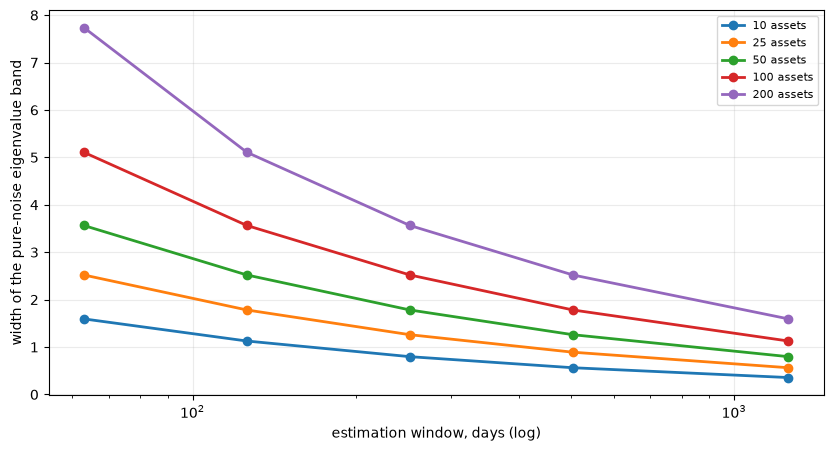

n_assets    10     25     50     100    200
window                                     
63       0.1590 0.3970 0.7940 1.5870 3.1750
126      0.0790 0.1980 0.3970 0.7940 1.5870
252      0.0400 0.0990 0.1980 0.3970 0.7940
504      0.0200 0.0500 0.0990 0.1980 0.3970
1260     0.0080 0.0200 0.0400 0.0790 0.1590


In [3]:
rows = []
for n_assets in (10, 25, 50, 100, 200):
    for window in (63, 126, 252, 504, 1260):
        b = st.marchenko_pastur_bounds(n_assets, window)
        rows.append({"n_assets": n_assets, "window": window, "q": b["q"],
                     "band_width": b["lambda_plus"] - b["lambda_minus"],
                     "lambda_plus": b["lambda_plus"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 5))
for n, g in d.groupby("n_assets"):
    ax.plot(g["window"], g["band_width"], "o-", lw=2, label=f"{n} assets")
ax.set_xscale("log"); ax.set_xlabel("estimation window, days (log)")
ax.set_ylabel("width of the pure-noise eigenvalue band"); ax.legend(fontsize=8)
plt.show()
print(d.pivot(index="window", columns="n_assets", values="q").round(3).to_string())

> \U0001F4A1 **In plain words.** This chart is free. Every allocator can read their own N and
> lookback off it before running anything, and most of the disappointment in covariance
> estimation is visible here in advance.

## 3 · The teardown

### 3.1 The empirical spectrum against the theoretical density

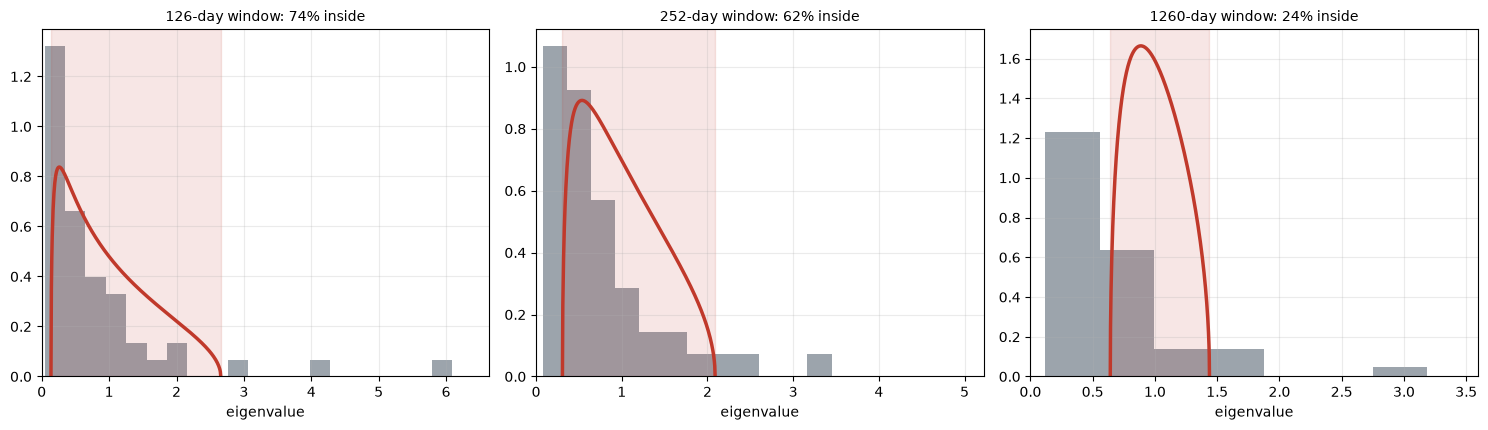

            q  lambda_plus  lambda_minus  n_above  share_inside  variance_above  largest_share  condition_number
window                                                                                                          
63     0.7937       3.5754        0.0119        3        0.9000          0.4361         0.2232        3,453.7268
126    0.3968       2.6567        0.1369        4        0.7400          0.4715         0.2126          247.2146
252    0.1984       2.0893        0.3075        5        0.6200          0.4664         0.1982          131.8773
504    0.0992       1.7291        0.4693        5        0.4400          0.5024         0.2744          166.9206
1260   0.0397       1.4381        0.6413        6        0.2400          0.5420         0.3094          129.9666
2520   0.0198       1.3016        0.7381        4        0.1400          0.5429         0.3907          193.4015


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, w in zip(axes, (126, 252, 1260)):
    if len(R) < w:
        continue
    s = st.spectrum_analysis(R.iloc[-w:])
    ax.hist(s["eigenvalues"], bins=35, density=True, color="#8b949e", alpha=0.85)
    xs = np.linspace(s["lambda_minus"], s["lambda_plus"], 400)
    ax.plot(xs, st.mp_density(xs, s["q"]), lw=2.5, color="#c0392b")
    ax.axvspan(s["lambda_minus"], s["lambda_plus"], alpha=0.12, color="#c0392b")
    ax.set_xlim(0, s["lambda_plus"] * 2.5)
    ax.set_title(f"{w}-day window: {s['share_inside']:.0%} inside", fontsize=10)
    ax.set_xlabel("eigenvalue")
plt.tight_layout(); plt.show()
print(st.spectrum_by_window(R, windows=(63, 126, 252, 504, 1260, 2520)).round(4)
      .to_string())

### 3.2 The control — calibrating before believing

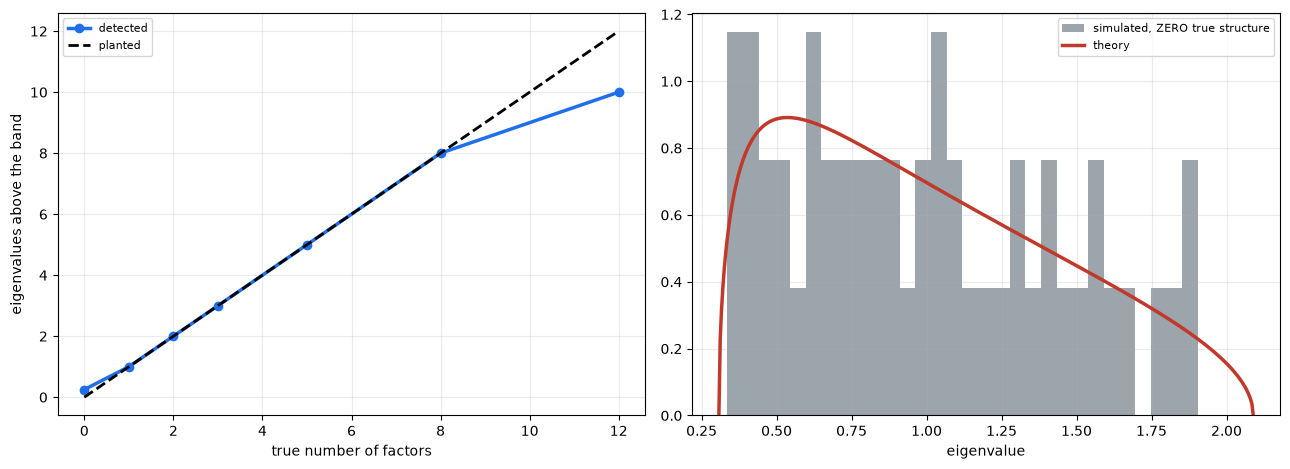

         detected  share_inside
planted                        
0          0.2500        0.9900
1          1.0000        0.7600
2          2.0000        0.5600
3          3.0000        0.4200
5          5.0000        0.1750
8          8.0000        0.0250
12        10.0000        0.0450


In [5]:
rows = []
for k in (0, 1, 2, 3, 5, 8, 12):
    for seed in range(4):
        sim = st.synthetic_returns(len(cols), 252, n_factors=k, factor_strength=1.0,
                                   seed=1010 + seed)
        s = st.spectrum_analysis(sim)
        rows.append({"planted": k, "detected": s["n_above"],
                     "share_inside": s["share_inside"]})
d = pd.DataFrame(rows).groupby("planted").mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(d.index, d["detected"], "o-", lw=2.5, color="#1f6feb", label="detected")
axes[0].plot(d.index, d.index, "k--", lw=2, label="planted")
axes[0].set_xlabel("true number of factors")
axes[0].set_ylabel("eigenvalues above the band"); axes[0].legend(fontsize=8)
sim0 = st.synthetic_returns(len(cols), 252, n_factors=0)
s0 = st.spectrum_analysis(sim0)
axes[1].hist(s0["eigenvalues"], bins=30, density=True, color="#8b949e", alpha=0.85,
             label="simulated, ZERO true structure")
xs = np.linspace(s0["lambda_minus"], s0["lambda_plus"], 400)
axes[1].plot(xs, st.mp_density(xs, s0["q"]), lw=2.5, color="#c0392b",
             label="theory")
axes[1].set_xlabel("eigenvalue"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(d.round(3).to_string())

### 3.3 What the surviving eigenvectors actually are

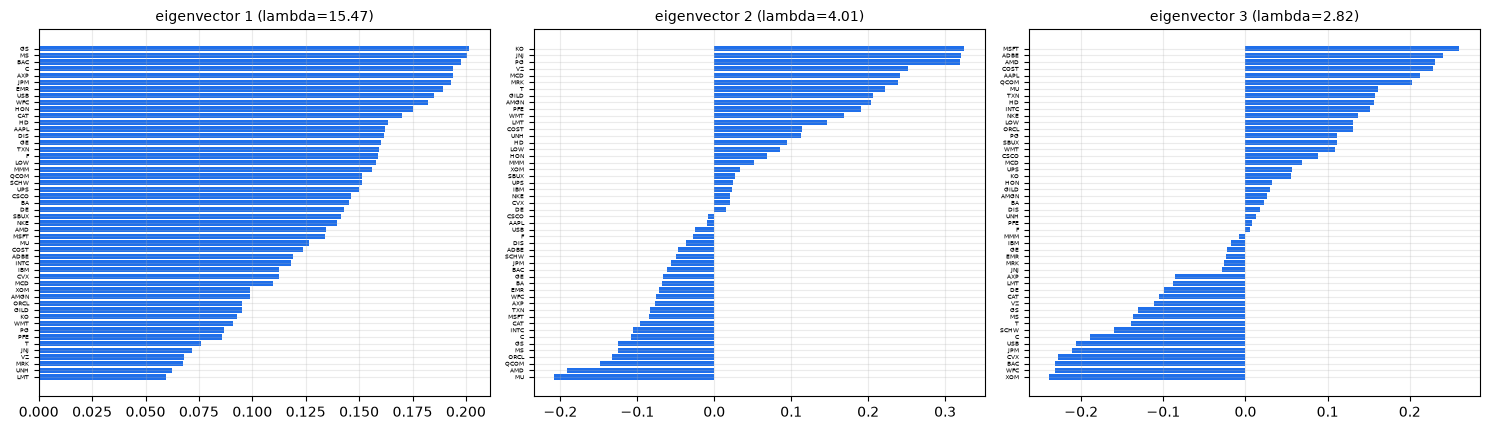

The first is all one sign -- that is 'the market'. The next two, if they escape
the band at all, are usually sector tilts. Beyond that there is nothing to name.


In [6]:
s = st.spectrum_analysis(R.iloc[-1260:])
C = np.corrcoef(R.iloc[-1260:].to_numpy().T)
vals, vecs = np.linalg.eigh(C)
order = np.argsort(vals)[::-1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for i, ax in enumerate(axes):
    v = vecs[:, order[i]]
    v = v * np.sign(v.sum())
    srt = np.argsort(v)
    ax.barh(range(len(v)), v[srt], color="#1f6feb")
    ax.set_yticks(range(len(v)))
    ax.set_yticklabels([cols[j] for j in srt], fontsize=4)
    ax.set_title(f"eigenvector {i+1} (lambda={vals[order[i]]:.2f})", fontsize=10)
plt.tight_layout(); plt.show()
print("The first is all one sign -- that is 'the market'. The next two, if they escape")
print("the band at all, are usually sector tilts. Beyond that there is nothing to name.")

### 3.4 Persistence, with and without the market

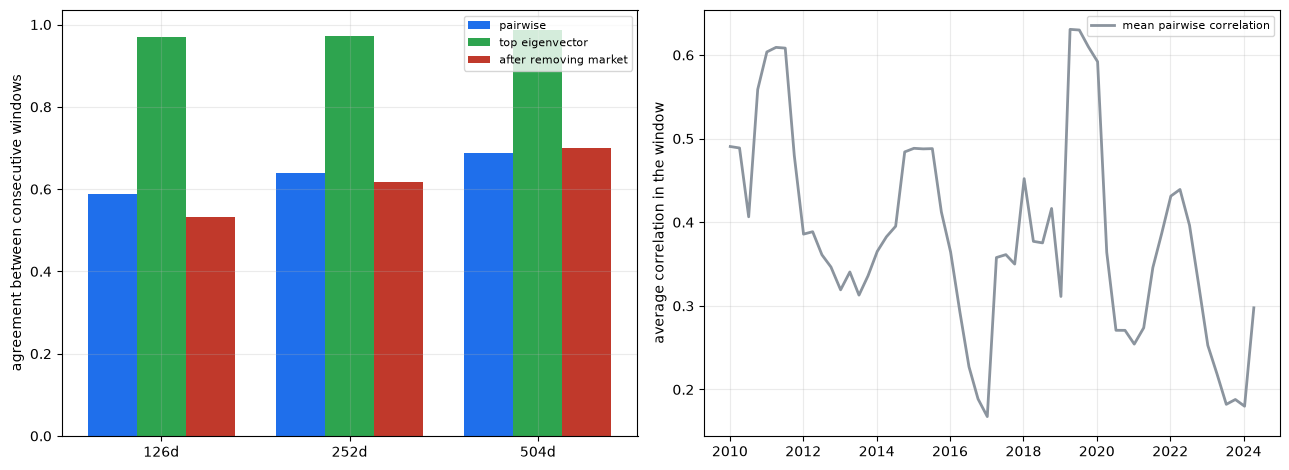

          n  pairwise  top_overlap  residual  pairwise_sd  residual_sd  mean_corr_drift
window                                                                                 
126     126    0.5871       0.9693    0.5331       0.0953       0.0977           0.1229
252      58    0.6383       0.9731    0.6170       0.0837       0.0765           0.1470
504      25    0.6890       0.9862    0.6991       0.0749       0.0489           0.1353


In [7]:
rows = []
for w in (126, 252, 504):
    p = st.matrix_persistence(R, window=w, step=max(w // 4, 21))
    s = st.persistence_summary(p)
    if s:
        rows.append({"window": w, **s})
d = pd.DataFrame(rows).set_index("window")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(len(d)); wd = 0.26
axes[0].bar(x - wd, d["pairwise"], wd, color="#1f6feb", label="pairwise")
axes[0].bar(x, d["top_overlap"], wd, color="#2ea44f", label="top eigenvector")
axes[0].bar(x + wd, d["residual"], wd, color="#c0392b", label="after removing market")
axes[0].set_xticks(x); axes[0].set_xticklabels([f"{w}d" for w in d.index])
axes[0].set_ylabel("agreement between consecutive windows")
axes[0].legend(fontsize=8)
p = st.matrix_persistence(R, window=252, step=63)
axes[1].plot(p["start"], p["mean_corr_a"], lw=2, color="#8b949e",
             label="mean pairwise correlation")
axes[1].set_ylabel("average correlation in the window"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(d.round(4).to_string())

> \U0001F4A1 **In plain words.** The green bars are high at every window: the market factor is
> genuinely stable and genuinely useful. The red bars are what remains of the matrix once you
> stop being impressed by that.

### 3.5 Scored against a known truth

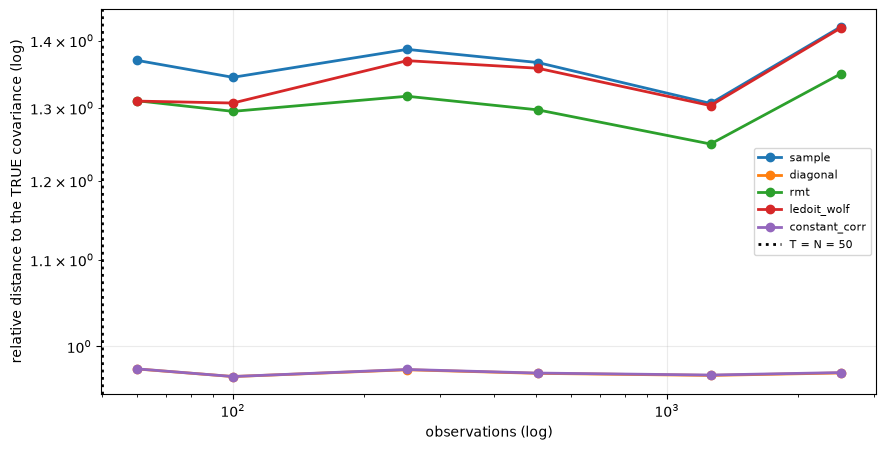

       sample  diagonal    rmt  ledoit_wolf  constant_corr
n_obs                                                     
60     1.3699    0.9755 1.3103       1.3098         0.9756
100    1.3445    0.9673 1.2950       1.3070         0.9674
252    1.3864    0.9746 1.3167       1.3693         0.9749
504    1.3665    0.9707 1.2972       1.3580         0.9710
1260   1.3064    0.9685 1.2493       1.3033         0.9689
2520   1.4217    0.9712 1.3500       1.4198         0.9716


In [8]:
rows = []
for n_obs in (60, 100, 252, 504, 1260, 2520):
    for seed in range(4):
        sim = st.synthetic_returns(len(cols), n_obs, n_factors=3, factor_strength=1.0,
                                   seed=1010 + seed)
        truth = st.true_covariance(len(cols), n_factors=3, factor_strength=1.0,
                                   seed=1010 + seed)
        rows.append({"n_obs": n_obs, **st.estimator_error(sim, truth)})
d = pd.DataFrame(rows).groupby("n_obs").mean()
fig, ax = plt.subplots(figsize=(10, 5))
for c in d.columns:
    ax.loglog(d.index, d[c], "o-", lw=2, label=c)
ax.axvline(len(cols), color="k", ls=":", lw=2, label=f"T = N = {len(cols)}")
ax.set_xlabel("observations (log)")
ax.set_ylabel("relative distance to the TRUE covariance (log)")
ax.legend(fontsize=8)
plt.show()
print(d.round(4).to_string())

### 3.6 The horse race, scored on calibration

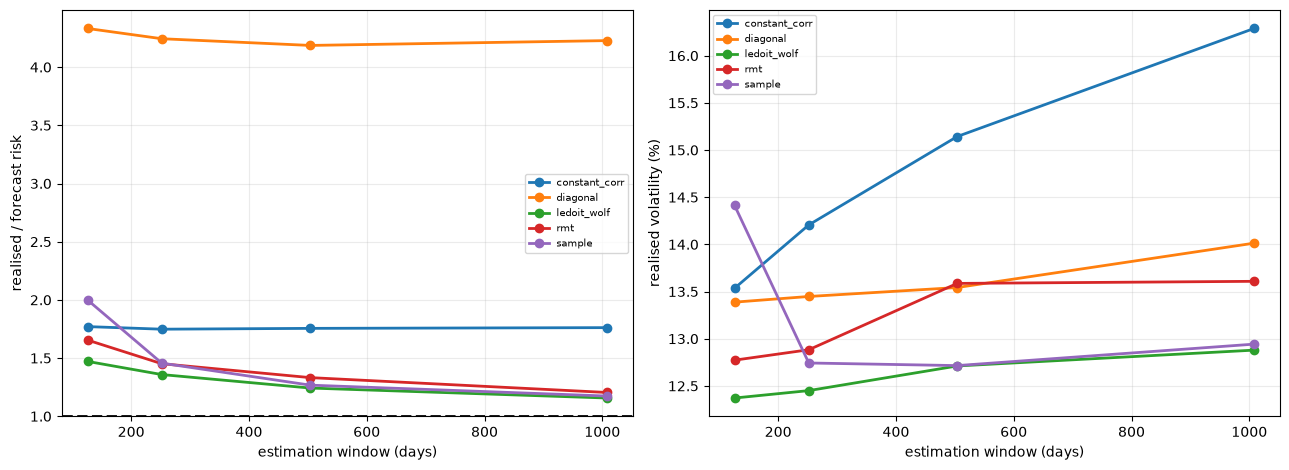

method  constant_corr  diagonal  ledoit_wolf    rmt  sample
window                                                     
126            1.7700    4.3320       1.4710 1.6550  1.9990
252            1.7480    4.2440       1.3580 1.4520  1.4570
504            1.7550    4.1860       1.2430 1.3320  1.2670
1008           1.7620    4.2280       1.1570 1.2040  1.1740


In [9]:
rows = []
for w, hd in ((126, 63), (252, 63), (504, 126), (1008, 126)):
    if len(R) < w + hd + 10:
        continue
    s = st.race_summary(st.portfolio_horse_race(R, w, hd))
    for m, row in s.iterrows():
        rows.append({"window": w, "method": m, **row.to_dict()})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for m, g in d.groupby("method"):
    axes[0].plot(g["window"], g["calibration"], "o-", lw=2, label=m)
    axes[1].plot(g["window"], g["realised_vol"] * 100, "o-", lw=2, label=m)
axes[0].axhline(1.0, color="k", ls="--", lw=2)
axes[0].set_xlabel("estimation window (days)")
axes[0].set_ylabel("realised / forecast risk"); axes[0].legend(fontsize=7)
axes[1].set_xlabel("estimation window (days)")
axes[1].set_ylabel("realised volatility (%)"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
print(d.pivot(index="window", columns="method", values="calibration").round(3)
      .to_string())

> \U0001F4A1 **In plain words.** A calibration above one means the optimiser under-forecast its
> own risk. It is not random error — the direction is systematic, because minimising a noisy
> variance estimate is the same operation as searching for the largest downward error in it.

### 3.7 What a constraint achieves for free

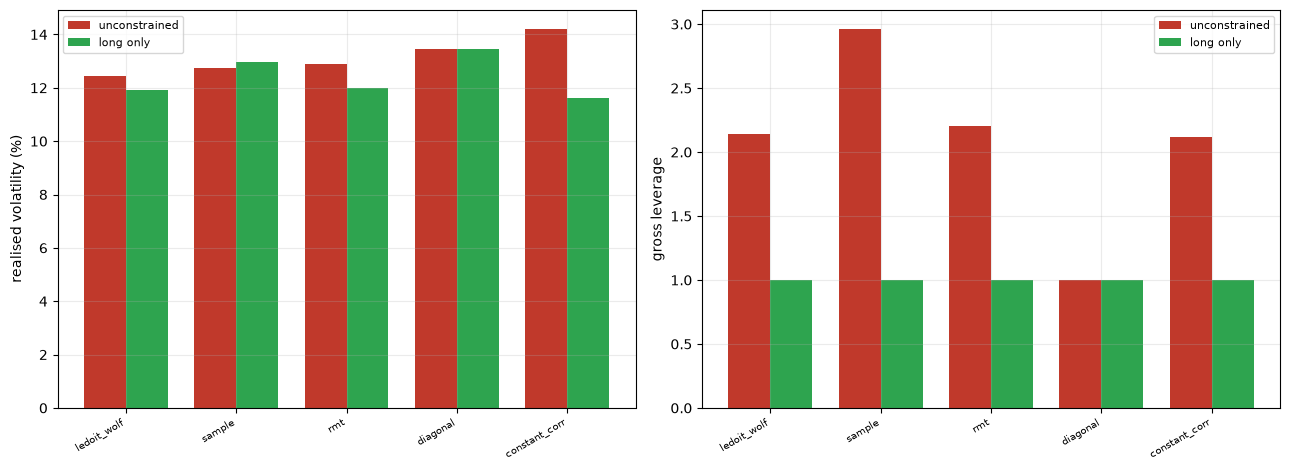

               unconstrained  long only
method                                 
constant_corr         0.1421     0.1161
diagonal              0.1345     0.1345
ledoit_wolf           0.1245     0.1190
rmt                   0.1288     0.1200
sample                0.1274     0.1297


In [10]:
free = st.race_summary(st.portfolio_horse_race(R, 252, 63, long_only=False))
cons = st.race_summary(st.portfolio_horse_race(R, 252, 63, long_only=True))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(len(free)); w = 0.38
order = free.index
axes[0].bar(x - w/2, free.loc[order, "realised_vol"] * 100, w, color="#c0392b",
            label="unconstrained")
axes[0].bar(x + w/2, cons.loc[order, "realised_vol"] * 100, w, color="#2ea44f",
            label="long only")
axes[0].set_xticks(x); axes[0].set_xticklabels(order, rotation=30, ha="right",
                                               fontsize=7)
axes[0].set_ylabel("realised volatility (%)"); axes[0].legend(fontsize=8)
axes[1].bar(x - w/2, free.loc[order, "gross_leverage"], w, color="#c0392b",
            label="unconstrained")
axes[1].bar(x + w/2, cons.loc[order, "gross_leverage"], w, color="#2ea44f",
            label="long only")
axes[1].set_xticks(x); axes[1].set_xticklabels(order, rotation=30, ha="right",
                                               fontsize=7)
axes[1].set_ylabel("gross leverage"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(pd.DataFrame({"unconstrained": free["realised_vol"],
                    "long only": cons["realised_vol"]}).round(4).to_string())

> \U0001F4A1 **In plain words.** Jagannathan & Ma (2003) proved a no-shorting constraint is
> mathematically equivalent to shrinking the covariance matrix. The right-hand panel is that
> theorem showing up in a bar chart: the constraint does most of the cleaning by itself, and
> the estimators then have far less left to disagree about.

## 4 · The verdict

In [11]:
s = st.spectrum_analysis(R.iloc[-252:])
ps = st.persistence_summary(st.matrix_persistence(R, 252, 63))
summ = st.race_summary(st.portfolio_horse_race(R, 252, 63))
p = st.parameters_vs_observations(len(cols), 252)
err = (summ["calibration"] - 1).abs()
pd.DataFrame({
    "assets": [len(cols)],
    "free parameters in the matrix": [p["n_parameters"]],
    "observations per parameter": [p["observations_per_parameter"]],
    "q = N/T": [s["q"]],
    "noise band, lower": [s["lambda_minus"]],
    "noise band, upper": [s["lambda_plus"]],
    "eigenvalues above the band": [s["n_above"]],
    "share of spectrum inside the band": [s["share_inside"]],
    "variance carried by the noise bulk": [s["variance_inside"]],
    "largest eigenvalue's share": [s["largest_share"]],
    "pairwise persistence": [ps["pairwise"]],
    "persistence after removing the market": [ps["residual"]],
    "raw matrix calibration": [summ.loc["sample", "calibration"]],
    "best-calibrated estimator": [str(err.idxmin())],
    "its calibration": [summ.loc[err.idxmin(), "calibration"]],
    "diagonal baseline calibration": [summ.loc["diagonal", "calibration"]],
}).T.rename(columns={0: "value"})

,value
assets,50
free parameters in the matrix,1275
observations per parameter,9.8824
q = N/T,0.1984
"noise band, lower",0.3075
"noise band, upper",2.0893
eigenvalues above the band,5
share of spectrum inside the band,0.6200
variance carried by the noise bulk,0.4781
largest eigenvalue's share,0.1982


## 5 · Going further

- **Bun, Bouchaud & Potters (2017)** give rotationally-invariant estimators that dominate the
  simple eigenvalue-clipping filter used in §3.6. Implementing one is the obvious upgrade and
  would probably change the ranking.
- **Marchenko-Pastur assumes i.i.d. Gaussian entries**, which returns are not. The true noise
  band under fat tails and volatility clustering is *wider*, so every "share inside the band"
  reported here is conservative. Deriving the correct band for a Student-t world would sharpen
  the whole study.
- **Jagannathan & Ma (2003)** explains §3.7 analytically: a no-short constraint is equivalent to
  shrinking the covariance matrix by a specific amount. Working out the implied shrinkage on
  this panel and comparing it against Ledoit-Wolf's δ would connect the two halves neatly.
- **Dynamic conditional correlation.** Everything here uses static windows. A DCC-GARCH model
  makes correlations time-varying by construction, and testing it on §3.6's calibration
  criterion — rather than on in-sample likelihood, which is how it is usually sold — would be a
  genuinely informative comparison.